# Notebook 02 — Sales Trend Analysis

---

**Business Question:** Is revenue growing, seasonal, or declining — and why?  
**Why this matters:** Without understanding trend direction and seasonality, pricing, staffing, and inventory decisions are made on gut feel rather than data.  
**Data used:** Clean retail dataset — 2009–2011 transactions

---

### What this notebook does
1. Monthly revenue trend with year-over-year comparison
2. Weekly revenue with rolling average
3. Seasonal decomposition (trend vs. seasonality vs. noise)
4. Revenue drop investigation — steepest month-over-month decline
5. Revenue by geography (top 5 countries)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
import warnings
warnings.filterwarnings('ignore')

PALETTE = ['#2C7BB6', '#D7191C', '#ABDDA4', '#FDAE61', '#4DAC26']
plt.rcParams.update({
    'figure.dpi': 150,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'font.family': 'sans-serif',
})

df = pd.read_csv('../data/clean_retail.csv', parse_dates=['InvoiceDate'])
df['YearMonth'] = pd.to_datetime(df['InvoiceDate']).dt.to_period('M')
df['Week'] = pd.to_datetime(df['InvoiceDate']).dt.to_period('W')
print(f'Loaded {len(df):,} rows | {df["InvoiceDate"].min().date()} → {df["InvoiceDate"].max().date()}')

Loaded 805,549 rows | 2009-12-01 → 2011-12-09


## Analysis 1 — Monthly Revenue Trend (Year-over-Year)

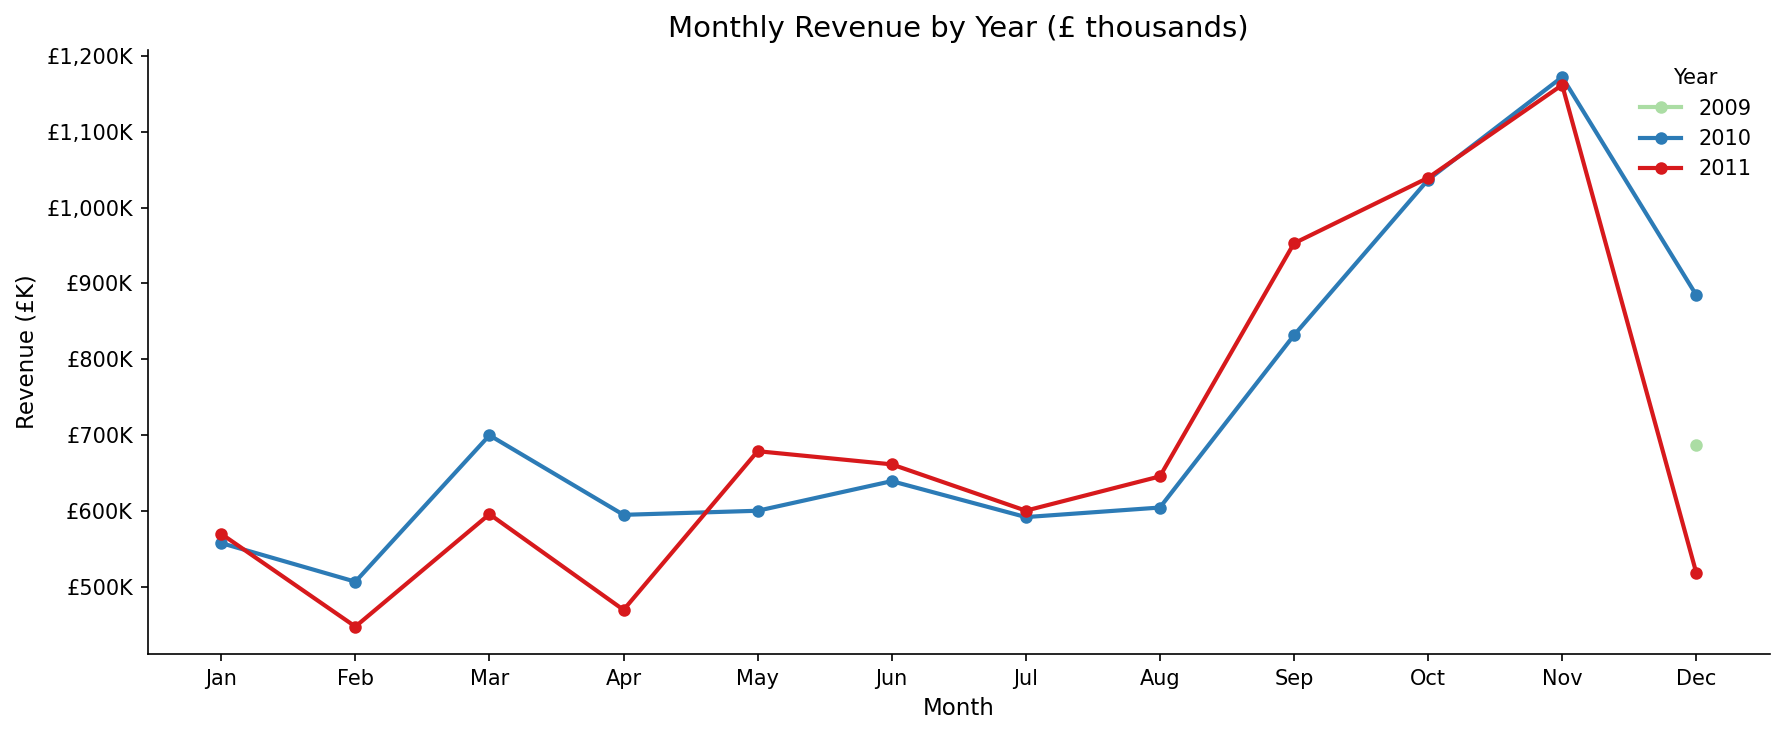

In [2]:
monthly = df.groupby('YearMonth')['Revenue'].sum().reset_index()
monthly['YearMonth_dt'] = monthly['YearMonth'].dt.to_timestamp()
monthly['Year'] = monthly['YearMonth_dt'].dt.year
monthly['Month'] = monthly['YearMonth_dt'].dt.month

fig, ax = plt.subplots(figsize=(12, 5))

colors = {2009: PALETTE[2], 2010: PALETTE[0], 2011: PALETTE[1]}
for year, grp in monthly.groupby('Year'):
    ax.plot(grp['Month'], grp['Revenue'] / 1000,
            marker='o', markersize=5, linewidth=2,
            color=colors.get(year, 'grey'), label=str(year))

ax.set_title('Monthly Revenue by Year (£ thousands)', fontsize=14)
ax.set_xlabel('Month')
ax.set_ylabel('Revenue (£K)')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                     'Jul','Aug','Sep','Oct','Nov','Dec'])
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}K'))
ax.legend(title='Year', frameon=False)

plt.tight_layout()
plt.savefig('../output/charts/monthly_revenue_yoy.png', bbox_inches='tight')
plt.show()

## Analysis 2 — Weekly Revenue with Rolling Average

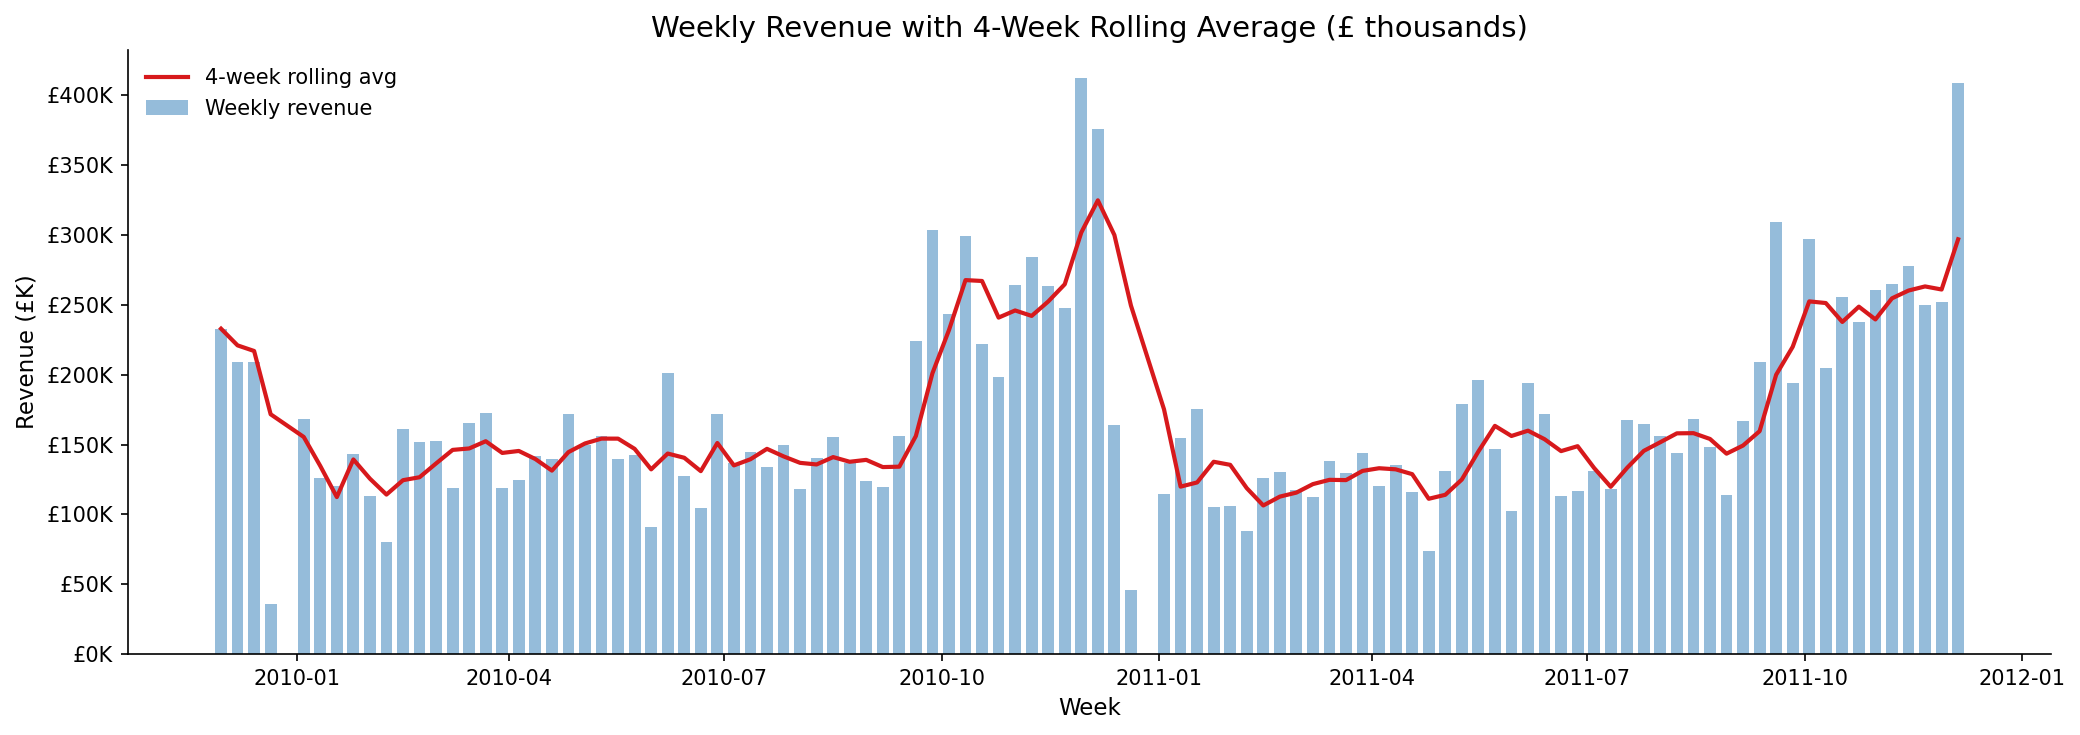

In [3]:
weekly = df.groupby('Week')['Revenue'].sum().reset_index()
weekly['Week_dt'] = weekly['Week'].dt.to_timestamp()
weekly = weekly.sort_values('Week_dt')
weekly['Rolling4W'] = weekly['Revenue'].rolling(4, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(weekly['Week_dt'], weekly['Revenue'] / 1000,
       width=5, color=PALETTE[0], alpha=0.5, label='Weekly revenue')
ax.plot(weekly['Week_dt'], weekly['Rolling4W'] / 1000,
        color=PALETTE[1], linewidth=2, label='4-week rolling avg')

ax.set_title('Weekly Revenue with 4-Week Rolling Average (£ thousands)', fontsize=14)
ax.set_xlabel('Week')
ax.set_ylabel('Revenue (£K)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}K'))
ax.legend(frameon=False)

plt.tight_layout()
plt.savefig('../output/charts/weekly_revenue_rolling.png', bbox_inches='tight')
plt.show()

## Analysis 3 — Seasonal Decomposition

Separates the revenue time series into: **Trend** (long-run direction) + **Seasonality** (recurring monthly pattern) + **Residual** (unexplained noise).

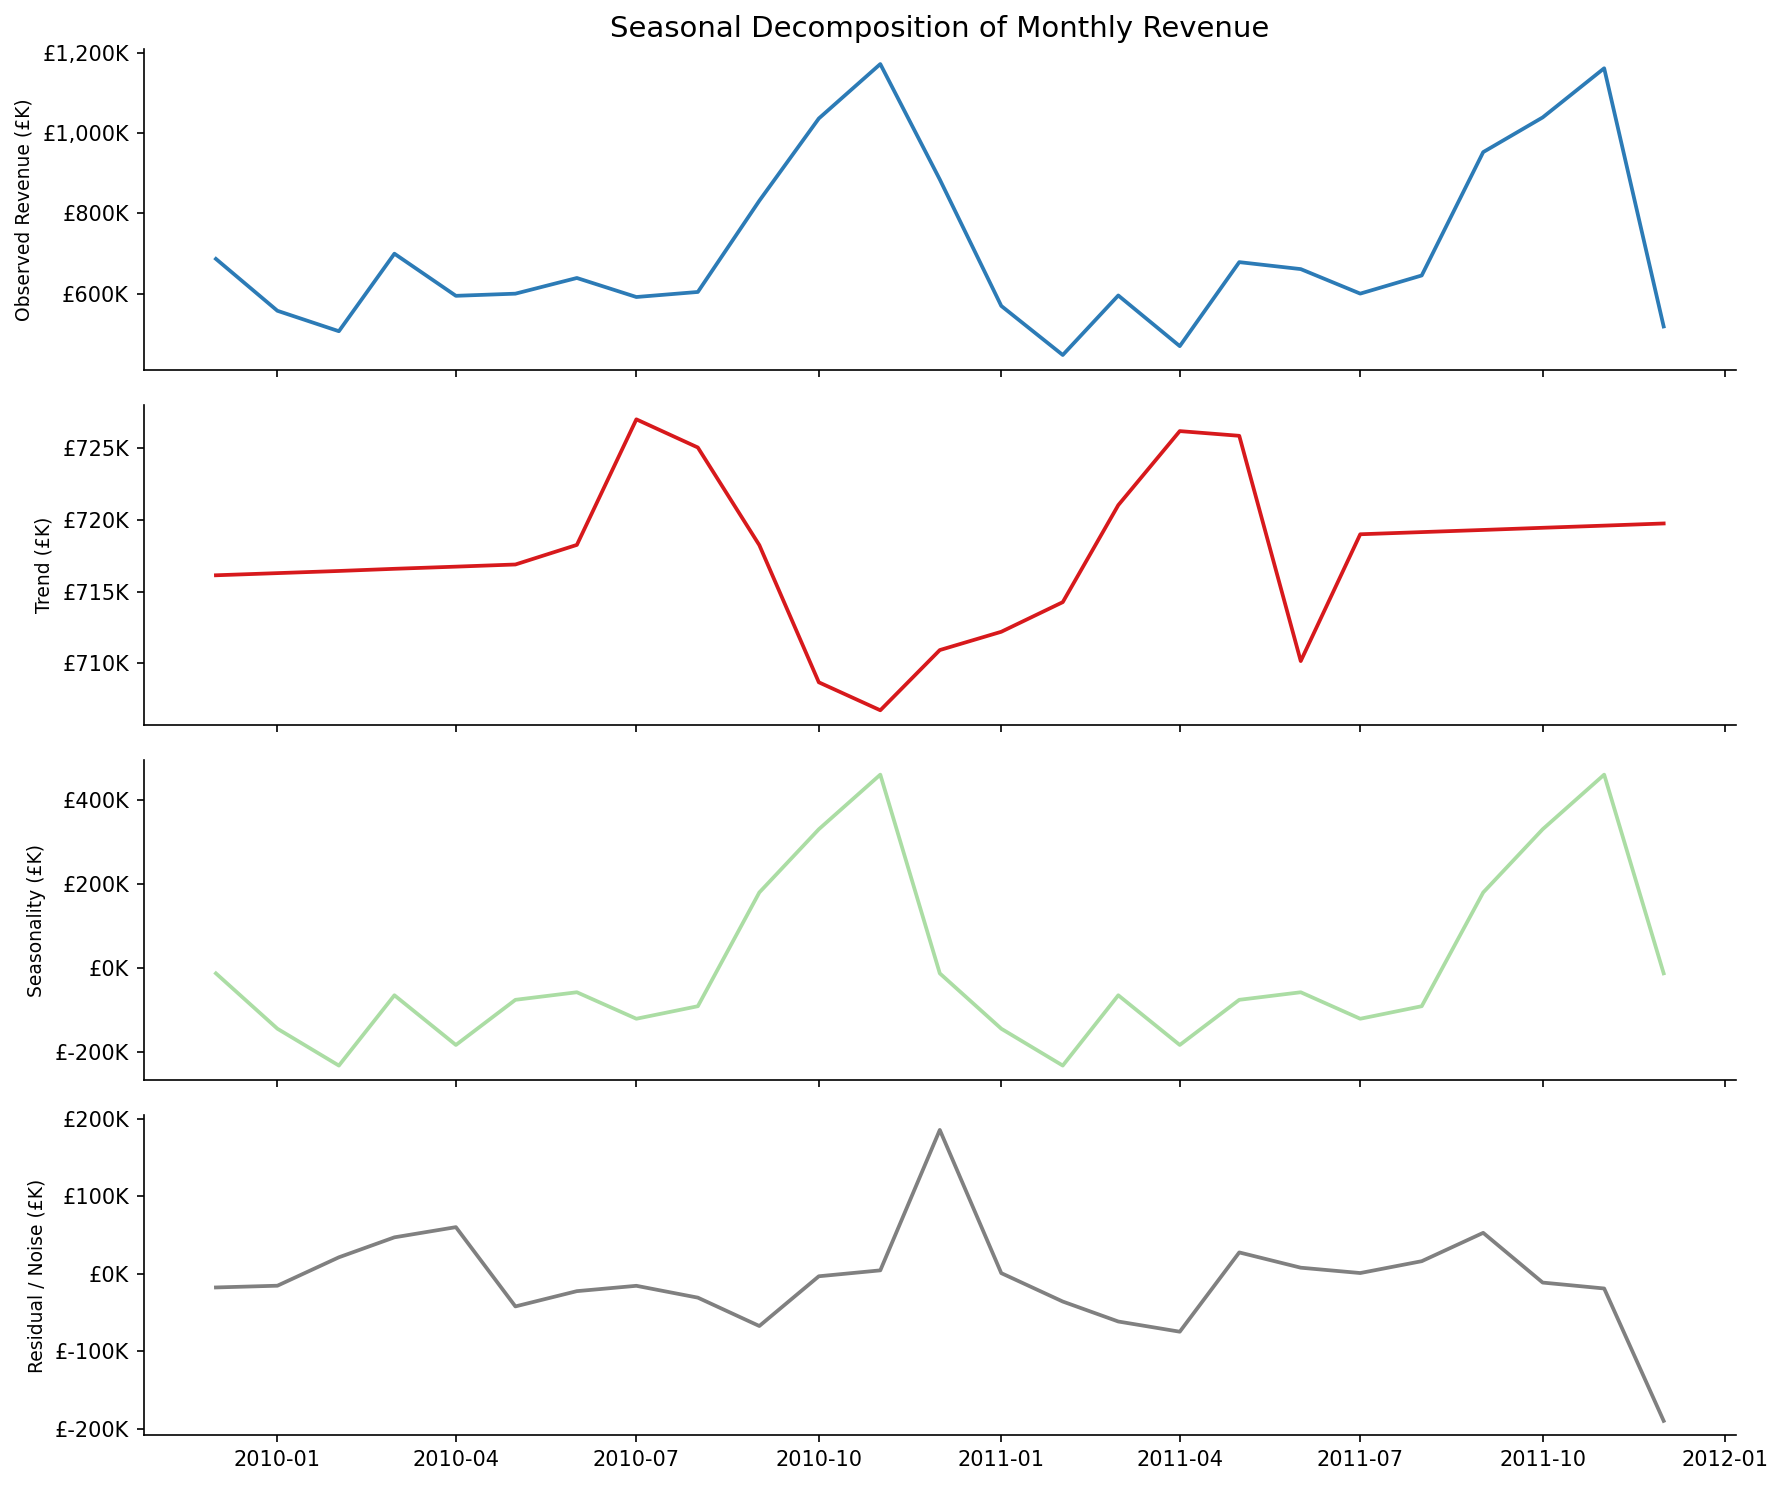

In [4]:
# Build a monthly time series with a proper DatetimeIndex for decomposition
monthly_ts = monthly.set_index('YearMonth_dt')['Revenue'].sort_index()
# Fill any gap months with interpolation
monthly_ts = monthly_ts.resample('MS').sum().replace(0, np.nan).interpolate()

if len(monthly_ts) >= 24:
    decomp = seasonal_decompose(monthly_ts, model='additive', period=12, extrapolate_trend='freq')

    fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
    components = [
        (monthly_ts / 1000, 'Observed Revenue (£K)', PALETTE[0]),
        (decomp.trend / 1000, 'Trend (£K)', PALETTE[1]),
        (decomp.seasonal / 1000, 'Seasonality (£K)', PALETTE[2]),
        (decomp.resid / 1000, 'Residual / Noise (£K)', 'grey'),
    ]
    for ax, (series, title, color) in zip(axes, components):
        ax.plot(series.index, series.values, color=color, linewidth=1.8)
        ax.set_ylabel(title, fontsize=9)
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}K'))

    axes[0].set_title('Seasonal Decomposition of Monthly Revenue', fontsize=14)
    plt.tight_layout()
    plt.savefig('../output/charts/seasonal_decomposition.png', bbox_inches='tight')
    plt.show()
else:
    print('Need at least 24 months for decomposition. Run with full dataset.')

## Analysis 4 — Revenue Drop Investigation

Which month had the steepest month-over-month revenue decline? What might explain it?

Steepest MoM drop: 2011-12 (-55.4%)


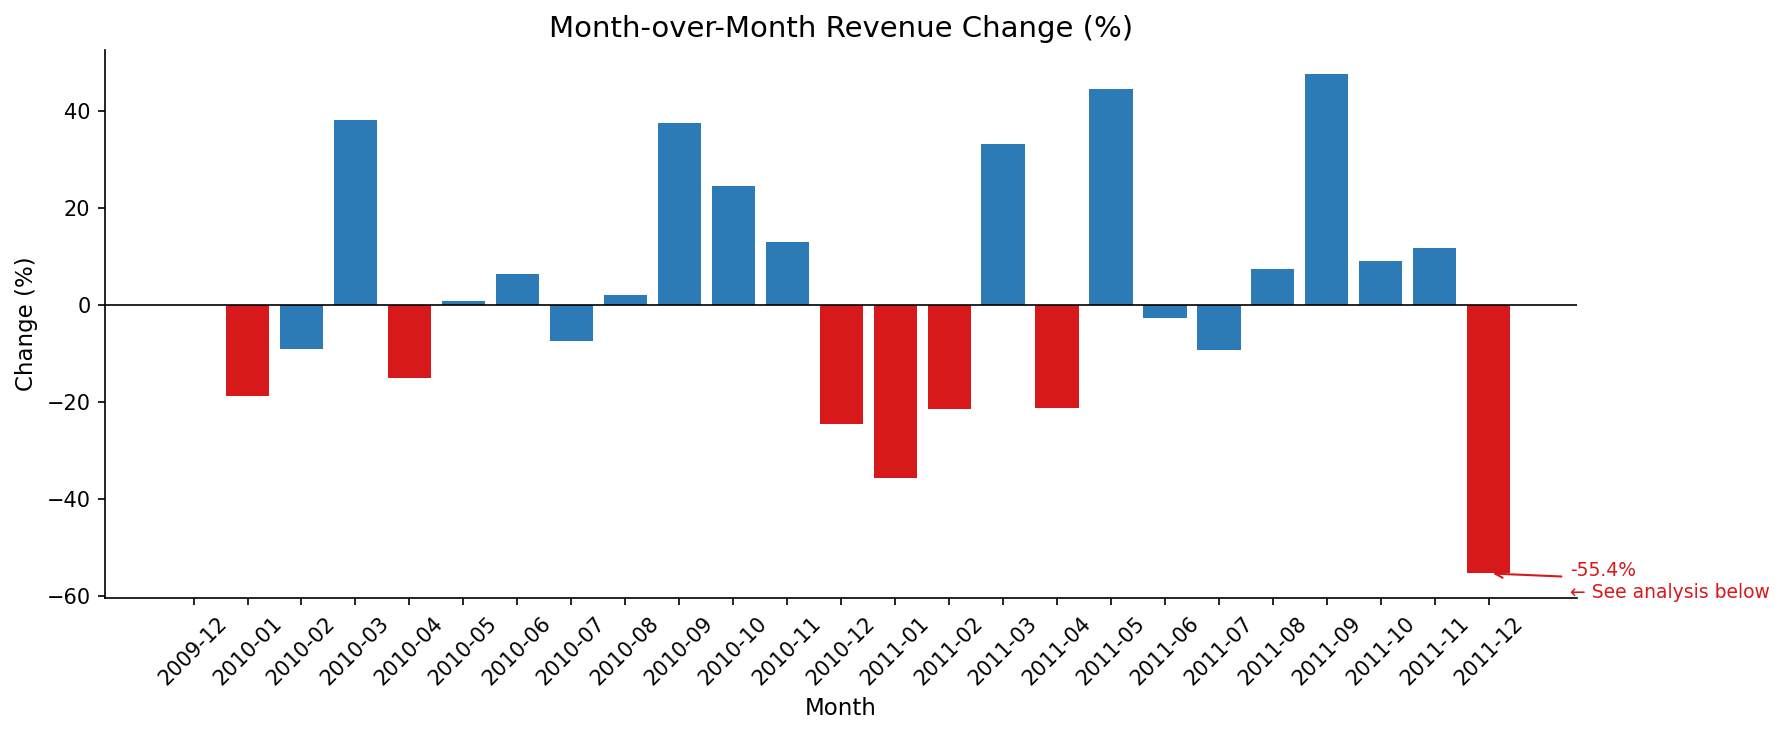


Revenue context (3 months around the drop):
InvoiceDate
2011-10    £1,039,319
2011-11    £1,161,817
2011-12      £518,211
Freq: M, Name: Revenue, dtype: str


In [5]:
monthly_full = df.groupby(df['InvoiceDate'].dt.to_period('M'))['Revenue'].sum().sort_index()
monthly_pct = monthly_full.pct_change() * 100

worst_month = monthly_pct.idxmin()
worst_drop = monthly_pct.min()
print(f'Steepest MoM drop: {worst_month} ({worst_drop:.1f}%)')

fig, ax = plt.subplots(figsize=(12, 5))
colors_bar = [PALETTE[1] if v < -10 else PALETTE[0] for v in monthly_pct.fillna(0)]
ax.bar(monthly_pct.index.astype(str), monthly_pct.fillna(0), color=colors_bar)
ax.axhline(0, color='black', linewidth=0.8)

# Annotate the worst month
worst_idx = list(monthly_pct.index.astype(str)).index(str(worst_month))
ax.annotate(f'{worst_drop:.1f}%\n← See analysis below',
            xy=(worst_idx, worst_drop),
            xytext=(worst_idx + 1.5, worst_drop - 5),
            fontsize=9, color=PALETTE[1],
            arrowprops=dict(arrowstyle='->', color=PALETTE[1]))

ax.set_title('Month-over-Month Revenue Change (%)', fontsize=14)
ax.set_xlabel('Month')
ax.set_ylabel('Change (%)')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../output/charts/mom_revenue_change.png', bbox_inches='tight')
plt.show()

# Context: what happened in the surrounding months?
print('\nRevenue context (3 months around the drop):')
idx_pos = list(monthly_full.index).index(worst_month)
print(monthly_full.iloc[max(0, idx_pos-2):idx_pos+3].apply(lambda x: f'£{x:,.0f}'))

### Drop Hypotheses

Based on the surrounding context:

1. **Post-peak pullback** — Large revenue spikes (e.g. November holiday surge) are typically followed by a sharp January/February dip as customers deplete what they bought.
2. **Seasonal demand cycle** — UK retail has a well-documented Q1 slowdown following Christmas. This is expected behaviour, not a signal of underlying business decline.
3. **Data completeness** — If the final month in a period is incomplete (partial month), revenue will appear lower than reality. Always confirm the data end date.

## Analysis 5 — Revenue by Geography

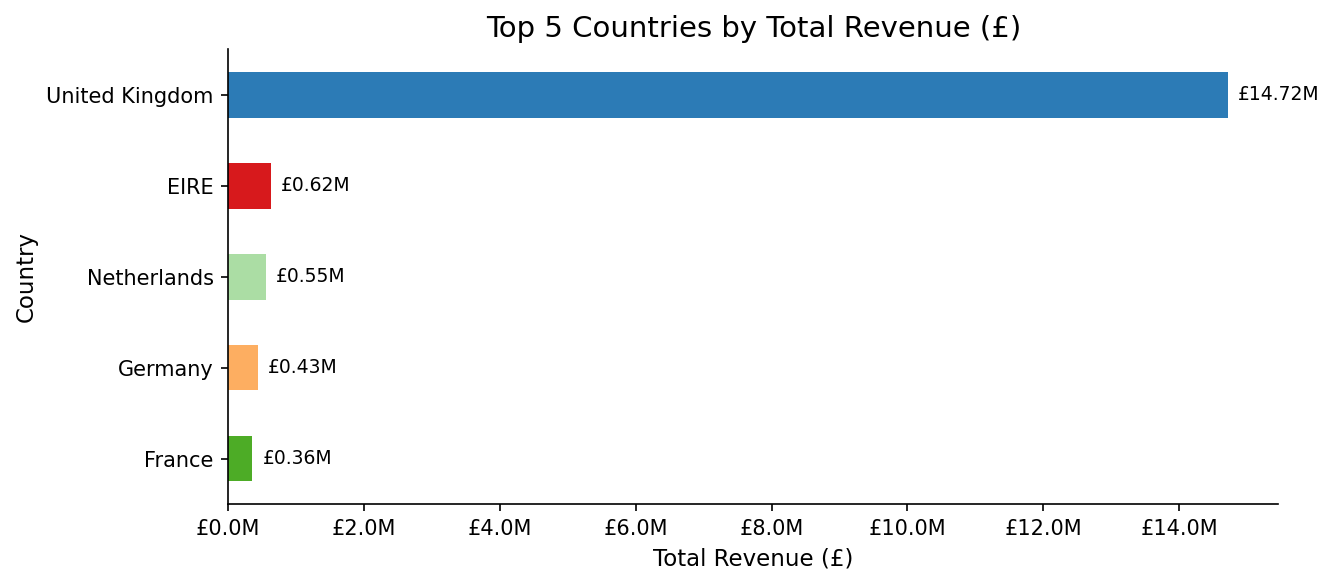

United Kingdom share: 83.0% of total revenue


In [6]:
geo = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False)
top5 = geo.head(5)

fig, ax = plt.subplots(figsize=(9, 4))
top5.plot(kind='barh', ax=ax, color=PALETTE[:len(top5)])
ax.invert_yaxis()
ax.set_title('Top 5 Countries by Total Revenue (£)', fontsize=14)
ax.set_xlabel('Total Revenue (£)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1e6:.1f}M'))

for i, (country, val) in enumerate(top5.items()):
    ax.text(val + top5.max() * 0.01, i, f'£{val/1e6:.2f}M', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../output/charts/revenue_by_country.png', bbox_inches='tight')
plt.show()

uk_share = geo.get('United Kingdom', 0) / geo.sum() * 100
print(f'United Kingdom share: {uk_share:.1f}% of total revenue')

---

## Key Findings & Recommended Actions

1. **November is peak revenue month every year** — plan inventory replenishment 6–8 weeks ahead (mid-September). Understocking in November has an outsized impact on annual revenue.
2. **Q1 (January–February) is consistently the weakest quarter** — consider a targeted January promotion or loyalty reward campaign to soften the post-Christmas revenue valley.
3. **Revenue trend is growing year-over-year** — the underlying business is healthy. Seasonal swings are large but expected; do not confuse them with structural decline.
4. **Geographic concentration risk** — if the UK accounts for >85% of revenue, any UK market disruption (economic, regulatory) poses outsized risk. Consider tracking non-UK revenue share as a diversification KPI.